In [1]:
from builder.lattice_surgery._cnot import CXExperiment

cx = CXExperiment(
    code_distance=3,
    control_state="X",
    target_state="Z",
    control_target_joint_measurement_basis="MZ",
)
cx.run_experiment()

In [2]:
from dotg.noise import DepolarizingNoise

noise_model = DepolarizingNoise(physical_error=1e-3)
noisy_circuit = noise_model.permute_circuit(cx.circuit)

In [3]:
from dotg.decoders import MinimumWeightPerfectMatching

decoder = MinimumWeightPerfectMatching(circuit=noisy_circuit)
decoder.logical_error(1e6)

0.016498

In [4]:
noisy_circuit.shortest_graphlike_error()

[stim.ExplainedError(dem_error_terms=(stim.DemTargetWithCoords(dem_target=stim.target_relative_detector_id(61), coords=[0.5, 4.5, 3]),stim.DemTargetWithCoords(dem_target=stim.target_relative_detector_id(74), coords=[1.5, 4.5, 3]),), circuit_error_locations=(stim.CircuitErrorLocation(tick_offset=16, flipped_pauli_product=(stim.GateTargetWithCoords(gate_target=stim.target_z(3), coords=[1, 4]),stim.GateTargetWithCoords(gate_target=stim.target_x(80), coords=[0.5, 4.5]),), flipped_measurement=stim.FlippedMeasurement(record_index=18446744073709551615, observable=()), instruction_targets=stim.CircuitTargetsInsideInstruction(gate='DEPOLARIZE2', args=[0.001], target_range_start=16, target_range_end=18, targets_in_range=(stim.GateTargetWithCoords(gate_target=3, coords=[1, 4]),stim.GateTargetWithCoords(gate_target=80, coords=[0.5, 4.5]),)), stack_frames=(stim.CircuitErrorLocationStackFrame(instruction_offset=247, iteration_index=0, instruction_repetitions_arg=0),)),stim.CircuitErrorLocation(tick_

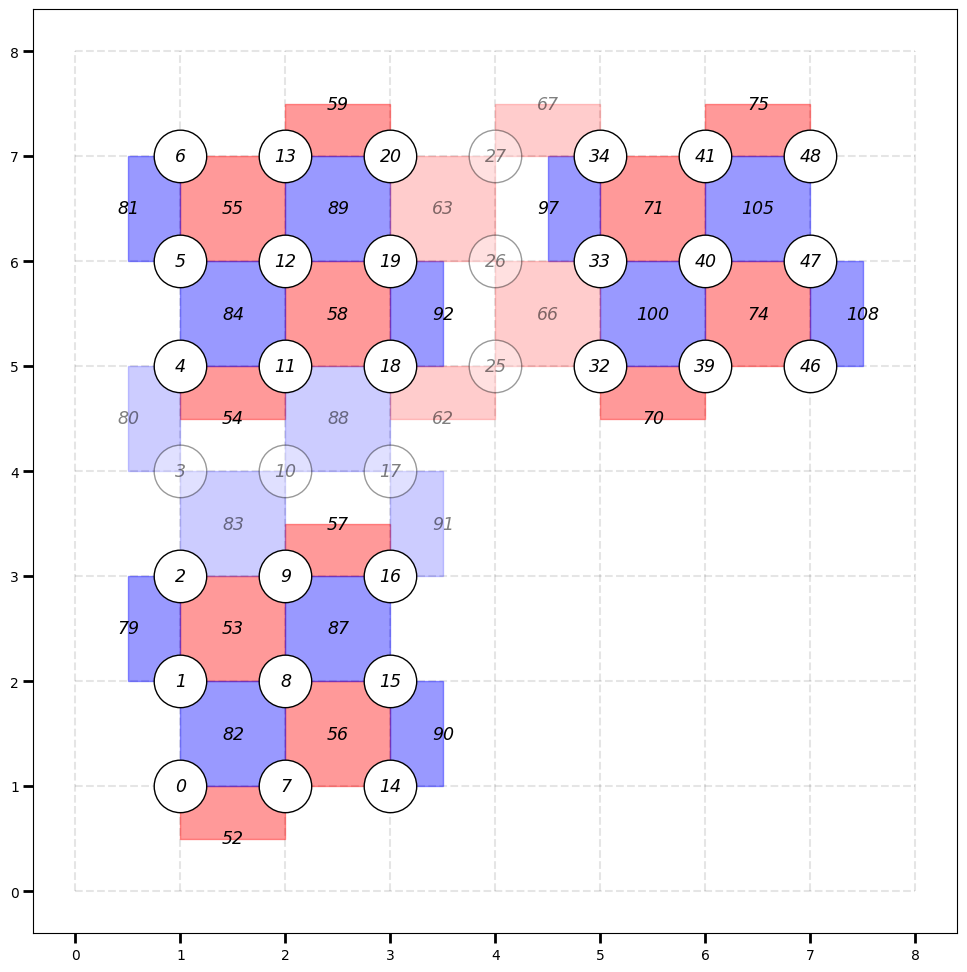

In [ ]:
cx.draw(show="all")

In [6]:
from builder.lattice_surgery import QuantumMemory

qmem = QuantumMemory(code_distance=(3, 3), num_qubits=3, bases=["X", "X", "Z"])
noisy_qmem = noise_model.permute_circuit(qmem.run_experiment(memory_rounds=12))
qmem_decoder = MinimumWeightPerfectMatching(circuit=noisy_qmem)
qmem_decoder.logical_error(1e6)

0.005197